In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load and inspect the gathered data
data=pd.read_csv("/content/test_zomato.csv")

#first 5 records of the data
data.head()


,Unnamed: 0,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,0,6317637,Le Petit Souffle,162.0,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,...,Botswana Pula(P),Yes,No,No,No,3.0,4.8,Dark Green,Excellent,314.0
1,1,6304287,Izakaya Kikufuji,162.0,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,...,Botswana Pula(P),Yes,No,No,No,3.0,4.5,Dark Green,Excellent,591.0
2,2,6300002,Heat - Edsa Shangri-La,162.0,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,...,Botswana Pula(P),Yes,No,No,No,4.0,4.4,Green,Very Good,270.0
3,3,6318506,Ooma,162.0,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,...,Botswana Pula(P),No,No,No,No,4.0,4.9,Dark Green,Excellent,365.0
4,4,6314302,Sambo Kojin,162.0,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.58445,...,Botswana Pula(P),Yes,No,No,No,4.0,4.8,Dark Green,Excellent,229.0


In [4]:
# Find the average restaurant rating
average_rating = data['Aggregate rating'].mean()

# Print the result rounded to 2 decimal places
print(f"The average restaurant rating is: {average_rating:.2f}")

The average restaurant rating is: 2.67


In [5]:
# dentify the restaurant with the highest number of votes
highest_votes_index = data['Votes'].idxmax()

# 2. Extract the restaurant name and its total votes using that index
# Note: If your column name is capitalized differently (e.g., 'restaurant_name'), update it below.
restaurant_name = data.loc[highest_votes_index, 'Restaurant Name']
max_votes = data.loc[highest_votes_index, 'Votes']

print(f"The restaurant with the highest number of votes is '{restaurant_name}' with {max_votes:,} votes.")


The restaurant with the highest number of votes is 'Toit' with 10,934.0 votes.


In [9]:
#Find the average cost for two across all restaurants
# 1. Clean the text data (removes any commas or spaces if they exist)
data["Average Cost for two"] = data["Average Cost for two"].astype(str).str.replace(',', '', regex=False).str.strip()

# 2. Force conversion to a numeric data type
# (errors='coerce' converts any corrupted text like "Missing" into a clean NaN blank space)
data["Average Cost for two"] = pd.to_numeric(data["Average Cost for two"], errors='coerce')

# 3. Now compute the average cost successfully
average_cost_for_two = data['Average Cost for two'].mean()

# 4. Print the final calculated result
print(f"The average cost for two across all restaurants is: {average_cost_for_two:.2f}")


The average cost for two across all restaurants is: 1199.33


In [10]:
#Compare the average ratings of restaurants that:
# 1. Group by online delivery status and calculate the average aggregate rating
delivery_comparison = data.groupby('Has Online delivery')['Aggregate rating'].mean()

# 2. Print the comparison metrics
print("--- Average Ratings Comparison ---")
print(f"Restaurants WITH Online Delivery:    {delivery_comparison['Yes']:.2f}")
print(f"Restaurants WITHOUT Online Delivery: {delivery_comparison['No']:.2f}")


--- Average Ratings Comparison ---
Restaurants WITH Online Delivery:    3.25
Restaurants WITHOUT Online Delivery: 2.47


In [11]:
# 1. Group by table booking status and calculate the average aggregate rating
booking_comparison = data.groupby('Has Table booking')['Aggregate rating'].mean()

# 2. Print the comparison metrics clearly
print("--- Average Ratings Comparison ---")
print(f"Restaurants WITH Table Booking:    {booking_comparison['Yes']:.2f}")
print(f"Restaurants WITHOUT Table Booking: {booking_comparison['No']:.2f}")


--- Average Ratings Comparison ---
Restaurants WITH Table Booking:    3.44
Restaurants WITHOUT Table Booking: 2.56


/tmp/ipykernel_523/3197780762.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


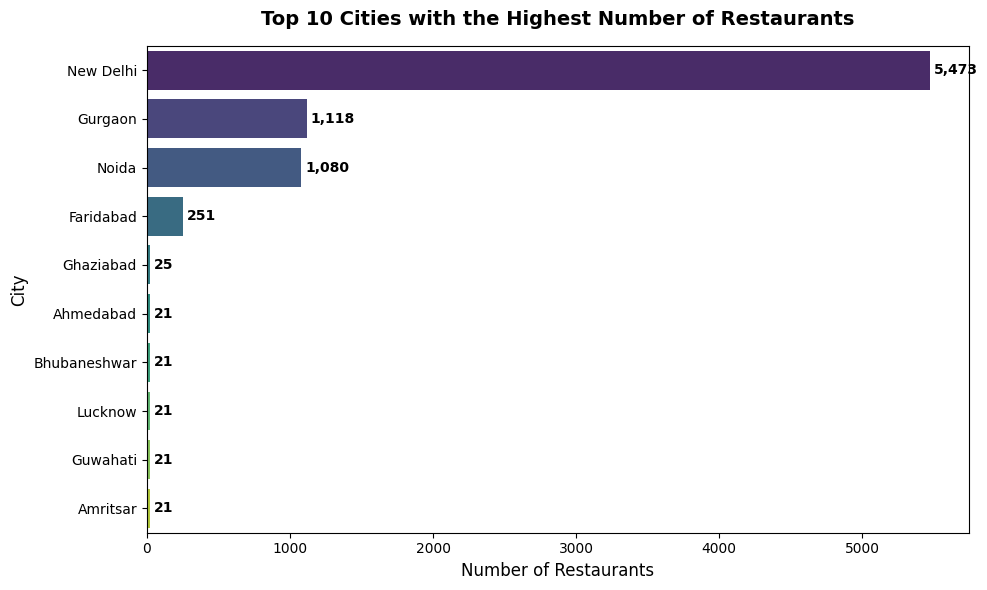

In [12]:
#PART 3 Data Visualization
#Create appropriate visualizations using Matplotlib and/or Seaborn
#Bar Chart -Top 10 cities with the highest number of restaurants
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the top 10 cities and their restaurant counts
top_10_cities = data['City'].value_counts().head(10)

# 2. Set up the plotting environment and size
plt.figure(figsize=(10, 6))

# 3. Create a horizontal bar chart
sns.barplot(
    x=top_10_cities.values,
    y=top_10_cities.index,
    palette='viridis'
)

# 4. Add labels, titles, and clean up aesthetics
plt.title('Top 10 Cities with the Highest Number of Restaurants', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('City', fontsize=12)

# 5. Add value labels on top of each bar for easier reading
for index, value in enumerate(top_10_cities.values):
    plt.text(value + (max(top_10_cities.values) * 0.005), index, f'{value:,}', va='center', fontweight='semibold')

# 6. Adjust layout and display the chart
plt.tight_layout()
plt.show()


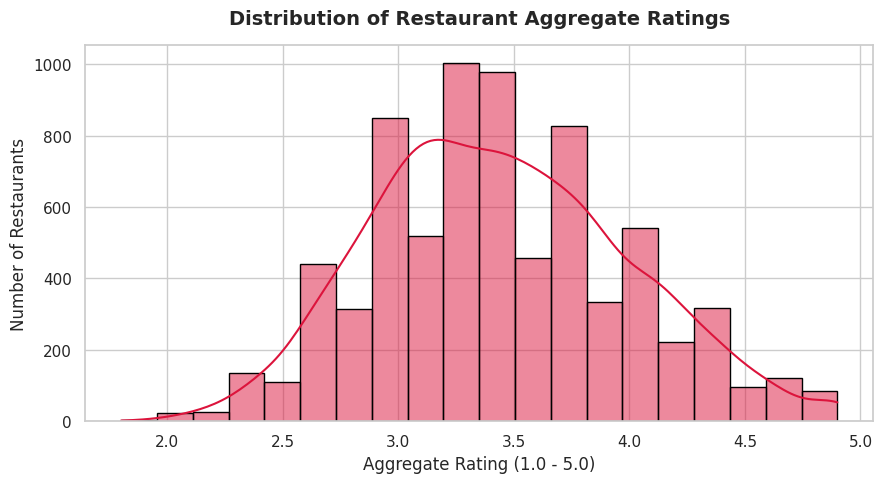

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
#Histogram- Distribution of Aggregate Rating
# 1. Set the style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# Optional: Filter out 0.0 ratings if they represent "Unrated" restaurants
# to see the true distribution of active user ratings.
# If you want to include 0s, change this to: filtered_ratings = data['Aggregate rating']
filtered_ratings = data[data['Aggregate rating'] > 0]['Aggregate rating']

# 2. Create the histogram with a trend line (KDE)
sns.histplot(
    filtered_ratings,
    bins=20,
    kde=True,
    color='crimson',
    edgecolor='black'
)

# 3. Add descriptive labels and title
plt.title('Distribution of Restaurant Aggregate Ratings', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Aggregate Rating (1.0 - 5.0)', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)

# 4. Show the plot
plt.tight_layout()
plt.show()


/tmp/ipykernel_523/904208477.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


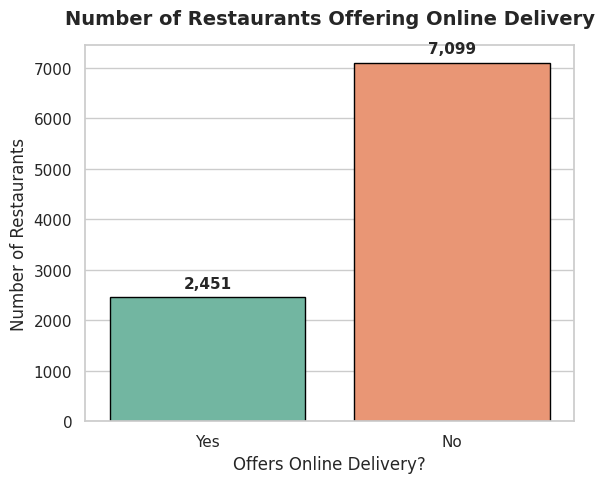

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
#Bar Chart- Number of restaurants offering Online Delivery (Yes/No)
# 1. Set the visual style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))

# 2. Create the bar chart using countplot (automatically counts 'Yes' and 'No')
ax = sns.countplot(
    x='Has Online delivery',
    data=data,
    order=['Yes', 'No'],
    palette='Set2',
    edgecolor='black'
)

# 3. Add titles and labels
plt.title('Number of Restaurants Offering Online Delivery', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Offers Online Delivery?', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)

# 4. Loop through the bars to display the exact counts on top
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='semibold',
        xytext=(0, 5),
        textcoords='offset points'
    )

# 5. Display the chart
plt.tight_layout()
plt.show()


/tmp/ipykernel_523/3839087363.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


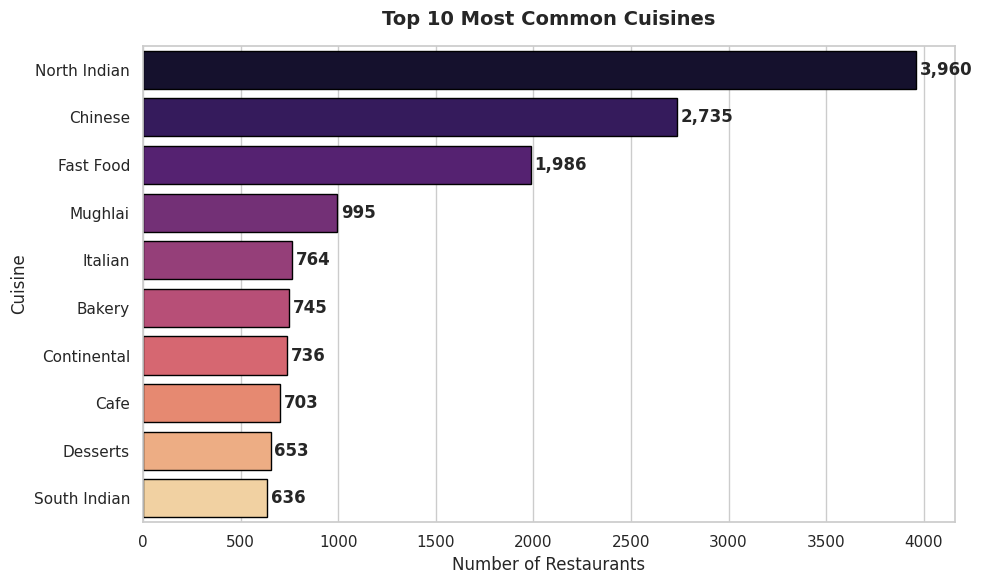

In [15]:
#Bar Chart-Top 10 most common cuisines
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Split individual cuisines by comma, clear white spaces, and flatten into a single series
all_cuisines = data['Cuisines'].dropna().str.split(',').explode().str.strip()

# 2. Get the top 10 most frequent individual cuisines
top_10_cuisines = all_cuisines.value_counts().head(10)

# 3. Set up the plotting size
plt.figure(figsize=(10, 6))

# 4. Create a horizontal bar chart
sns.barplot(
    x=top_10_cuisines.values,
    y=top_10_cuisines.index,
    palette='magma',
    edgecolor='black'
)

# 5. Add clean labels, titles, and formatting
plt.title('Top 10 Most Common Cuisines', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)

# 6. Add exact values at the end of each bar
for index, value in enumerate(top_10_cuisines.values):
    plt.text(
        value + (max(top_10_cuisines.values) * 0.005),
        index,
        f'{value:,}',
        va='center',
        fontweight='semibold'
    )

# 7. Display the chart
plt.tight_layout()
plt.show()


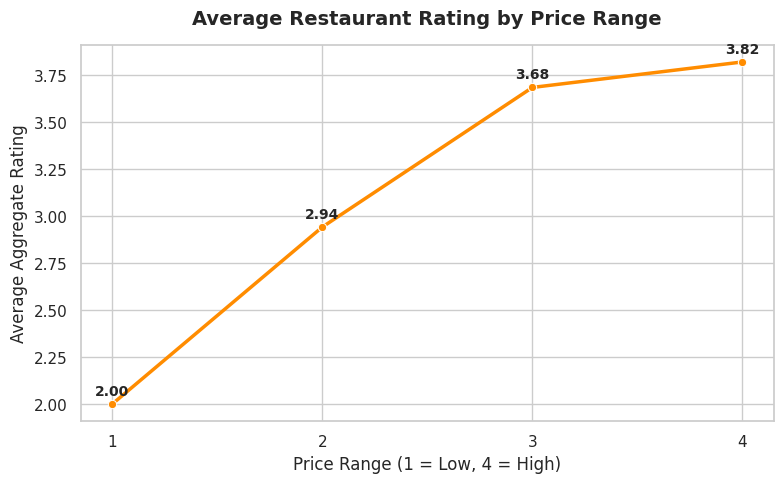

In [18]:
#ine Chart- Average restaurant rating by Price Range
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by 'Price range' (corrected lowercase 'r') and calculate the mean
price_rating_series = data.groupby('Price range')['Aggregate rating'].mean()

# 2. Set the visual style and figure size
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# 3. Plot the line chart with markers at data points
sns.lineplot(
    x=price_rating_series.index,
    y=price_rating_series.values,
    marker='o',
    linewidth=2.5,
    color='darkorange'
)

# 4. Add titles and labels
plt.title('Average Restaurant Rating by Price Range', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price Range (1 = Low, 4 = High)', fontsize=12)
plt.ylabel('Average Aggregate Rating', fontsize=12)

# 5. Fix X-axis intervals to show only discrete price ranges
plt.xticks(price_rating_series.index)

# 6. Add exact values above each marker point
for x, y in zip(price_rating_series.index, price_rating_series.values):
    plt.text(x, y + 0.05, f'{y:.2f}', ha='center', fontweight='semibold', fontsize=10)

# 7. Adjust layout and display the chart
plt.tight_layout()
plt.show()


In [20]:
#PART 4 -Which city has the highest restaurant presence
import pandas as pd

# Get the shape (returns a tuple: (rows, columns))
dataset_shape = data.shape

print(f"The shape of the dataset is: {dataset_shape}")
print(f"Number of rows: {dataset_shape[0]}")
print(f"Number of columns: {dataset_shape[1]}")


The shape of the dataset is: (9552, 22)
Number of rows: 9552
Number of columns: 22


In [21]:
#What is the most popular cuisine
# Print the absolute most frequent cuisine
print(data['Cuisines'].value_counts().idxmax())


North Indian


In [22]:
#Do restaurants with Online Delivery generally have higher ratings
# Check the exact average rating difference
print(data.groupby('Has Online delivery')['Aggregate rating'].mean())


Has Online delivery
No        2.465192
Orange         NaN
Yes       3.248837
Name: Aggregate rating, dtype: float64


In [23]:
#Do restaurants with Online Delivery generally have higher ratings
# Check the exact average rating difference
print(data.groupby('Has Online delivery')['Aggregate rating'].mean())


Has Online delivery
No        2.465192
Orange         NaN
Yes       3.248837
Name: Aggregate rating, dtype: float64


In [24]:
#Do restaurants offering Table Booking receive better ratings
# Check the exact average rating difference for your data
print(data.groupby('Has Table booking')['Aggregate rating'].mean())


Has Table booking
3.2         NaN
No     2.559283
Yes    3.441969
Name: Aggregate rating, dtype: float64
